# 06A — Augmented Results Analysis (1985–2020 two-stage pipeline)

**Purpose:** Results analysis and visualisation for the augmented two-stage model.

**Input:** `data/processed/augmented_analysis/` — outputs from NB05A

**Key differences vs NB06:**
- Loads Stage 1 (M1, M2 on 1988–2020) and Stage 2 (M2-matched, M3 on 2003–2020) OOS files separately
- Bootstrap CIs computed within each stage (different denominators)
- SHAP analysis uses Stage 2 M3 (2003–2020 only — sentiment features present)
- Country error audit runs on Stage 1 M2 (extended panel) for macro robustness assessment

---

## Cell 1 — Imports and paths

In [3]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.utils import resample
import shap, xgboost as xgb, tempfile, os

BASE    = Path(r'C:\Users\Owner\OneDrive\dissertation')
AUG_DIR = BASE / 'data' / 'processed' / 'augmented_analysis'
FIG_DIR = BASE / 'figures' / 'augmented_analysis'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Load datasets
df_macro    = pd.read_csv(AUG_DIR / 'df_macro_augmented.csv')
df_sent     = pd.read_csv(AUG_DIR / 'df_sent_augmented.csv')
results_df  = pd.read_csv(AUG_DIR / 'augmented_model_results.csv')
shap_df     = pd.read_csv(AUG_DIR / 'augmented_shap_values_m3.csv')
oos_s1      = pd.read_csv(AUG_DIR / 'oos_predictions_stage1.csv')   # M1, M2 (1988–2020)
oos_s2      = pd.read_csv(AUG_DIR / 'oos_predictions_stage2.csv')   # M2m, M3 (2003–2020)
M1_FEATURES = pd.read_csv(AUG_DIR / 'M1_features.csv', header=None)[0].tolist()
M2_FEATURES = pd.read_csv(AUG_DIR / 'M2_features.csv', header=None)[0].tolist()
M3_FEATURES = pd.read_csv(AUG_DIR / 'M3_features.csv', header=None)[0].tolist()

TARGET = next(c for c in oos_s1.columns if 'target' in c.lower())

y_s1 = oos_s1[TARGET].values   # Stage 1 true labels
y_s2 = oos_s2[TARGET].values   # Stage 2 true labels

print(f'Target          : {TARGET}')
print(f'Stage 1 events  : {int(y_s1.sum())}  rows: {len(oos_s1)}')
print(f'Stage 2 events  : {int(y_s2.sum())}  rows: {len(oos_s2)}')
print()
print(results_df.to_string(index=False))

Target          : target_h2
Stage 1 events  : 37  rows: 569
Stage 2 events  : 26  rows: 319

                                     Model Stage  Events    AUROC    AUPRC    Brier  AUPRC_lift
       M1 Logistic (macro lag1, 1988–2020)    S1      37 0.606329 0.138701 0.157343    2.133002
   M1b LR bridge (macro lag1-3, 1988–2020)    S1      37 0.645460 0.145395 0.135477    2.235936
M2 Random Forest (macro lag1-3, 1988–2020)    S1      37 0.635861 0.224223 0.059468    3.448192
   M2-matched RF (macro lag1-3, 2003–2020)    S2      26 0.938503 0.342754 0.060175    4.205325
M3 XGBoost+FinBERT (macro+sent, 2003–2020)    S2      26 0.931595 0.411046 0.060756    5.043219


## Cell 2 — Bootstrap metrics with CIs (Stage 1 and Stage 2)

In [5]:
def bootstrap_metrics(y_true, y_prob, n_boot=1000, seed=42):
    rng = np.random.RandomState(seed)
    auroc_scores, auprc_scores = [], []
    for _ in range(n_boot):
        idx = resample(np.arange(len(y_true)), random_state=rng)
        if y_true[idx].sum() == 0: continue
        auroc_scores.append(roc_auc_score(y_true[idx], y_prob[idx]))
        auprc_scores.append(average_precision_score(y_true[idx], y_prob[idx]))
    ci_auroc = np.percentile(auroc_scores, [2.5, 97.5])
    ci_auprc = np.percentile(auprc_scores, [2.5, 97.5])
    return ci_auroc, ci_auprc

print('=' * 80)
print(' STAGE 1 METRICS — M1 and M2 on extended panel (1988–2020)')
print('=' * 80)
base_s1 = y_s1.mean()
print(f' {"Model":<30} {"AUROC":>7} {"95% CI":>14} {"AUPRC":>7} {"AUPRC/Base":>11} {"Brier":>7}')
print('-' * 80)
records = []
for name, col in [('M1 Logistic (macro lag1)', 'prob_m1'), ('M2 RF (macro lag1-3)', 'prob_m2')]:
    yp = oos_s1[col].values
    mask = ~np.isnan(yp)
    yt, ypc = y_s1[mask], yp[mask]
    if yt.sum() == 0: continue
    auroc = roc_auc_score(yt, ypc); auprc = average_precision_score(yt, ypc)
    brier = brier_score_loss(yt, ypc); lift = auprc / base_s1
    ci_a, ci_p = bootstrap_metrics(yt, ypc)
    print(f' {name:<30} {auroc:>7.4f} [{ci_a[0]:.3f},{ci_a[1]:.3f}] {auprc:>7.4f} {lift:>10.1f}x {brier:>7.4f}')
    records.append({'Stage':'S1','Model':name,'AUROC':auroc,'AUPRC':auprc,'Brier':brier})

print()
print('=' * 80)
print(' STAGE 2 METRICS — M2-matched and M3 on sentiment period (2003–2020)')
print('=' * 80)
base_s2 = y_s2.mean()
print(f' {"Model":<30} {"AUROC":>7} {"95% CI":>14} {"AUPRC":>7} {"AUPRC/Base":>11} {"Brier":>7}')
print('-' * 80)
for name, col in [('M2-matched RF (2003–2020)', 'prob_m2m'), ('M3 XGB+FinBERT (2003–2020)', 'prob_m3')]:
    yp = oos_s2[col].values
    mask = ~np.isnan(yp)
    yt, ypc = y_s2[mask], yp[mask]
    if yt.sum() == 0: continue
    auroc = roc_auc_score(yt, ypc); auprc = average_precision_score(yt, ypc)
    brier = brier_score_loss(yt, ypc); lift = auprc / base_s2
    ci_a, ci_p = bootstrap_metrics(yt, ypc)
    print(f' {name:<30} {auroc:>7.4f} [{ci_a[0]:.3f},{ci_a[1]:.3f}] {auprc:>7.4f} {lift:>10.1f}x {brier:>7.4f}')
    records.append({'Stage':'S2','Model':name,'AUROC':auroc,'AUPRC':auprc,'Brier':brier})

pd.DataFrame(records).to_csv(AUG_DIR / 'augmented_metrics_with_ci.csv', index=False)
print()
print('NOTE: Bootstrap CIs understate uncertainty due to panel dependence.')
print('      Stage 1 CIs reflect 39 events; Stage 2 CIs reflect 26 events.')

 STAGE 1 METRICS — M1 and M2 on extended panel (1988–2020)
 Model                            AUROC         95% CI   AUPRC  AUPRC/Base   Brier
--------------------------------------------------------------------------------
 M1 Logistic (macro lag1)        0.6063 [0.477,0.739]  0.1387        2.1x  0.1573
 M2 RF (macro lag1-3)            0.6359 [0.484,0.781]  0.2242        3.4x  0.0595

 STAGE 2 METRICS — M2-matched and M3 on sentiment period (2003–2020)
 Model                            AUROC         95% CI   AUPRC  AUPRC/Base   Brier
--------------------------------------------------------------------------------
 M2-matched RF (2003–2020)       0.9385 [0.897,0.970]  0.3428        4.2x  0.0602
 M3 XGB+FinBERT (2003–2020)      0.9316 [0.875,0.979]  0.4110        5.0x  0.0608

NOTE: Bootstrap CIs understate uncertainty due to panel dependence.
      Stage 1 CIs reflect 39 events; Stage 2 CIs reflect 26 events.


## Cell 3 — SHAP feature attribution (M3, Stage 2)

SHAP attribution by lag group (M3, Stage 2 data):
macro_lag1    2.816403
macro_lag3    2.735359
sent_lag1     1.325013
macro_lag2    1.248707
sent_lag2     1.083402

Macro share : 73.8%
Sentiment share : 26.2%


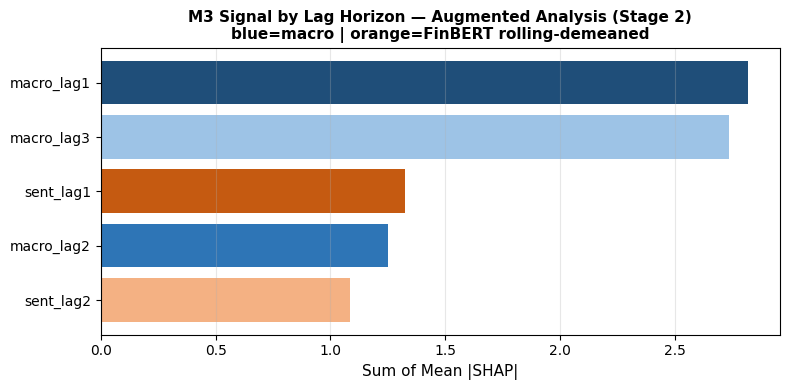

Saved → C:\Users\Owner\OneDrive\dissertation\figures\augmented_analysis/augmented_shap_lag_depth.png


In [7]:
shap_values = shap_df.values
mean_abs    = pd.Series(np.abs(shap_values).mean(axis=0), index=M3_FEATURES)

SENT_KEYS = ['P_pos','P_neg','P_neutral','net_sent','P_neg_change',
             'P_pos_change','net_sent_change','roll3','slope4']

def get_group(f):
    is_sent = any(s in f for s in SENT_KEYS)
    if '_lag1' in f and is_sent: return 'sent_lag1'
    if '_lag2' in f and is_sent: return 'sent_lag2'
    if '_lag1' in f: return 'macro_lag1'
    if '_lag2' in f: return 'macro_lag2'
    if '_lag3' in f: return 'macro_lag3'
    return 'other'

groups  = pd.Series({f: get_group(f) for f in M3_FEATURES})
lag_imp = mean_abs.groupby(groups).sum().reindex(
    ['macro_lag1','macro_lag2','macro_lag3','sent_lag1','sent_lag2','other']).dropna()
lag_imp = lag_imp.sort_values(ascending=False)

total = lag_imp.sum()
macro_share = lag_imp[['macro_lag1','macro_lag2','macro_lag3']].sum() / total
sent_share  = lag_imp[['sent_lag1','sent_lag2']].sum() / total

print('SHAP attribution by lag group (M3, Stage 2 data):')
print(lag_imp.to_string())
print(f'\nMacro share : {100*macro_share:.1f}%')
print(f'Sentiment share : {100*sent_share:.1f}%')

palette = {'macro_lag1':'#1F4E79','macro_lag2':'#2E75B6','macro_lag3':'#9DC3E6',
           'sent_lag1':'#C55A11','sent_lag2':'#F4B183','other':'#AAAAAA'}
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(lag_imp.index[::-1], lag_imp.values[::-1],
        color=[palette.get(g,'#999') for g in lag_imp.index[::-1]])
ax.set_xlabel('Sum of Mean |SHAP|', fontsize=11)
ax.set_title('M3 Signal by Lag Horizon — Augmented Analysis (Stage 2)\n'
             'blue=macro | orange=FinBERT rolling-demeaned', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(FIG_DIR / 'augmented_shap_lag_depth.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIG_DIR}/augmented_shap_lag_depth.png')

## Cell 4 — Top-20 SHAP features and temporal probability plot

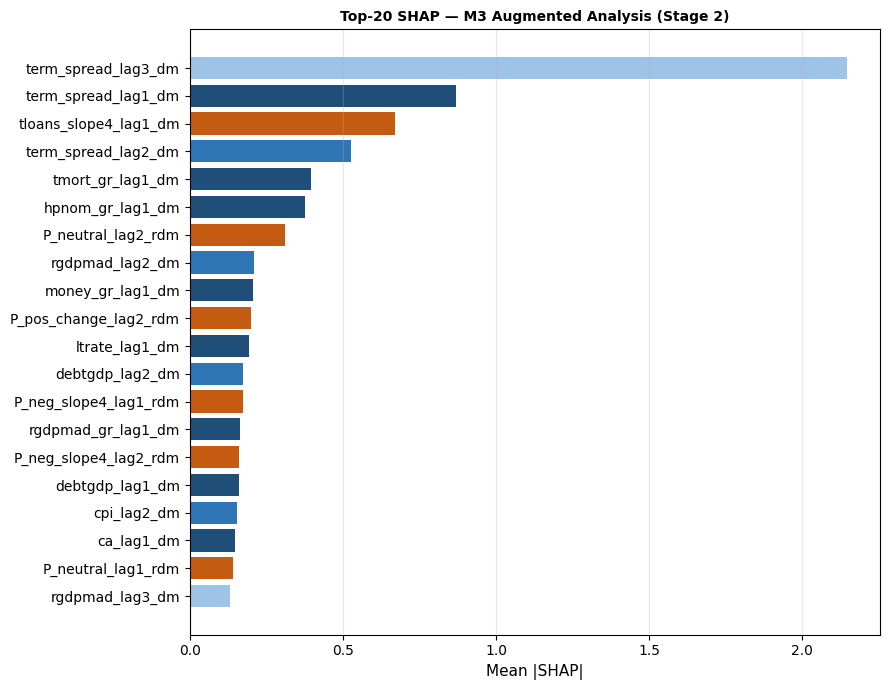

In [9]:
mean_abs_sorted = mean_abs.sort_values(ascending=True).tail(20)
def fc(f): return ('#C55A11' if any(s in f for s in SENT_KEYS) else
                   ('#9DC3E6' if '_lag3' in f else ('#2E75B6' if '_lag2' in f else '#1F4E79')))
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(mean_abs_sorted.index, mean_abs_sorted.values,
        color=[fc(f) for f in mean_abs_sorted.index])
ax.set_xlabel('Mean |SHAP|', fontsize=11)
ax.set_title('Top-20 SHAP — M3 Augmented Analysis (Stage 2)', fontsize=10, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(FIG_DIR / 'augmented_shap_top20.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 5 — Temporal probability plots (Stage 1 and Stage 2)

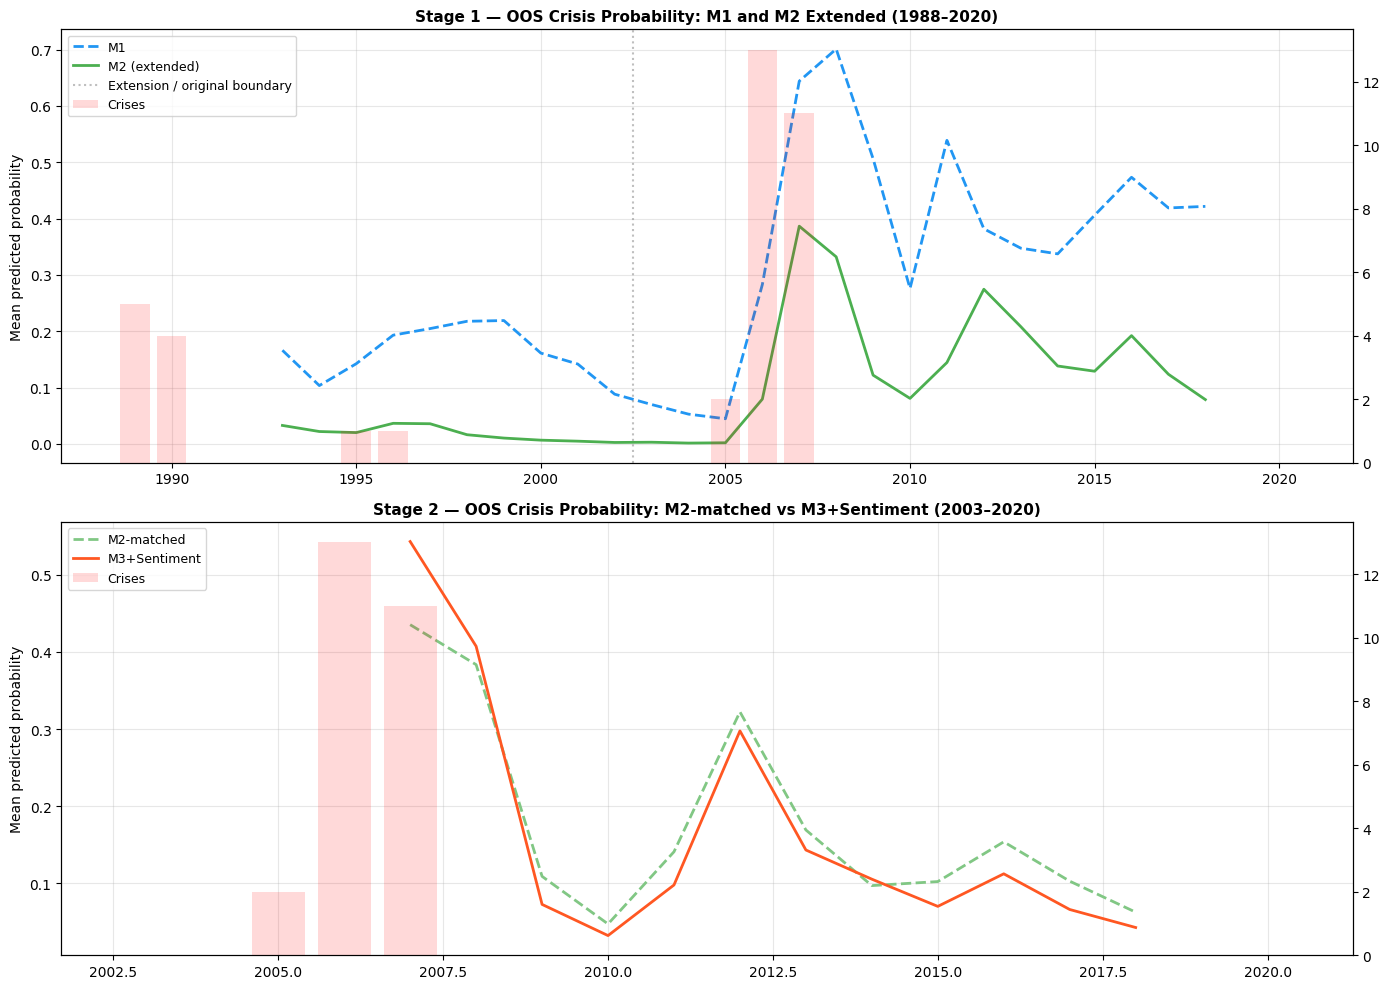

Saved → C:\Users\Owner\OneDrive\dissertation\figures\augmented_analysis/augmented_temporal_probs.png


In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Stage 1: M1 and M2 over full 1988–2020
ax = axes[0]
yearly_s1 = oos_s1.groupby('year').agg(
    prob_m1=('prob_m1','mean'), prob_m2=('prob_m2','mean'),
    actual=(TARGET,'sum')).reset_index()
ax2 = ax.twinx()
ax.plot(yearly_s1['year'], yearly_s1['prob_m1'], color='#2196F3', lw=2, label='M1', ls='--')
ax.plot(yearly_s1['year'], yearly_s1['prob_m2'], color='#4CAF50', lw=2, label='M2 (extended)')
ax2.bar(yearly_s1['year'], yearly_s1['actual'], alpha=0.15, color='red', label='Crises')
ax.axvline(2002.5, color='grey', linestyle=':', alpha=0.5, label='Extension / original boundary')
l1,lb1 = ax.get_legend_handles_labels(); l2,lb2 = ax2.get_legend_handles_labels()
ax.legend(l1+l2, lb1+lb2, loc='upper left', fontsize=9)
ax.set_title('Stage 1 — OOS Crisis Probability: M1 and M2 Extended (1988–2020)',
             fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3); ax.set_ylabel('Mean predicted probability')

# Stage 2: M2-matched and M3 over 2003–2020
ax = axes[1]
yearly_s2 = oos_s2.groupby('year').agg(
    prob_m2m=('prob_m2m','mean'), prob_m3=('prob_m3','mean'),
    actual=(TARGET,'sum')).reset_index()
ax2 = ax.twinx()
ax.plot(yearly_s2['year'], yearly_s2['prob_m2m'], color='#81C784', lw=2, label='M2-matched', ls='--')
ax.plot(yearly_s2['year'], yearly_s2['prob_m3'],  color='#FF5722', lw=2, label='M3+Sentiment')
ax2.bar(yearly_s2['year'], yearly_s2['actual'], alpha=0.15, color='red', label='Crises')
l1,lb1 = ax.get_legend_handles_labels(); l2,lb2 = ax2.get_legend_handles_labels()
ax.legend(l1+l2, lb1+lb2, loc='upper left', fontsize=9)
ax.set_title('Stage 2 — OOS Crisis Probability: M2-matched vs M3+Sentiment (2003–2020)',
             fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3); ax.set_ylabel('Mean predicted probability')

plt.tight_layout()
plt.savefig(FIG_DIR / 'augmented_temporal_probs.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIG_DIR}/augmented_temporal_probs.png')

## Cell 6 — Bootstrap AUPRC difference: M3 vs M2-matched (Stage 2)

In [13]:
from sklearn.utils import resample

print('=== BOOTSTRAP AUPRC DIFFERENCE: M3 vs M2-matched (Stage 2) ===')
print()

mask   = ~(np.isnan(oos_s2['prob_m2m'].values) | np.isnan(oos_s2['prob_m3'].values))
yt_d   = y_s2[mask]
yp_m2m = oos_s2['prob_m2m'].values[mask]
yp_m3  = oos_s2['prob_m3'].values[mask]

N_BOOT = 2000; diffs = []; rng = np.random.RandomState(42)
for _ in range(N_BOOT):
    idx = resample(np.arange(len(yt_d)), random_state=rng)
    yt_b, y2_b, y3_b = yt_d[idx], yp_m2m[idx], yp_m3[idx]
    if yt_b.sum() == 0: continue
    try:
        diffs.append(average_precision_score(yt_b,y3_b) - average_precision_score(yt_b,y2_b))
    except: pass

ci_lo, ci_hi = np.percentile(diffs, [2.5, 97.5])
point_diff   = average_precision_score(yt_d, yp_m3) - average_precision_score(yt_d, yp_m2m)

print(f'Point estimate: M3 AUPRC - M2-matched AUPRC = {point_diff:+.4f}')
print(f'Bootstrap 95% CI: [{ci_lo:+.4f}, {ci_hi:+.4f}]  ({N_BOOT} resamples)')
print()
if ci_lo > 0:
    verdict = 'CI entirely positive — M3 advantage statistically distinguishable from zero'
elif ci_hi < 0:
    verdict = 'CI entirely negative — M2-matched advantage statistically distinguishable from zero'
else:
    verdict = 'CI includes zero — advantage is directional but not statistically confirmed'
print(f'Verdict: {verdict}')
print()
print('This is the cleanest sentiment test in the augmented design: both models')
print('trained on identical 2003–2020 data, same CV, M3 adds only FinBERT features.')

pd.DataFrame({'metric':['M3_minus_M2matched_AUPRC','CI_lo','CI_hi'],
              'value':[point_diff,ci_lo,ci_hi]}).to_csv(
    AUG_DIR/'augmented_auprc_difference_ci.csv', index=False)
print('Saved augmented_auprc_difference_ci.csv')

=== BOOTSTRAP AUPRC DIFFERENCE: M3 vs M2-matched (Stage 2) ===

Point estimate: M3 AUPRC - M2-matched AUPRC = +0.0683
Bootstrap 95% CI: [-0.1295, +0.3121]  (2000 resamples)

Verdict: CI includes zero — advantage is directional but not statistically confirmed

This is the cleanest sentiment test in the augmented design: both models
trained on identical 2003–2020 data, same CV, M3 adds only FinBERT features.
Saved augmented_auprc_difference_ci.csv


In [14]:
print('=' * 65)
print(' NB06A AUGMENTED RESULTS ANALYSIS COMPLETE')
print('=' * 65)
print()
print('Figures:')
for f in sorted(FIG_DIR.glob('augmented_*.png')):
    print(f'  {f.name}')
print()
print('Next: Run NB07A_Augmented_Granger_Causality.ipynb')

 NB06A AUGMENTED RESULTS ANALYSIS COMPLETE

Figures:
  augmented_crisis_frequency.png
  augmented_roc_pr_curves.png
  augmented_shap_lag_depth.png
  augmented_shap_top20.png
  augmented_temporal_probs.png

Next: Run NB07A_Augmented_Granger_Causality.ipynb


In [15]:
## from sklearn.calibration import calibration_curve
import numpy as np

def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    n = len(y_true)
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (y_prob >= lo) & (y_prob < hi)
        if mask.sum() == 0:
            continue
        bin_acc  = y_true[mask].mean()
        bin_conf = y_prob[mask].mean()
        ece += (mask.sum() / n) * abs(bin_acc - bin_conf)
    return ece

print('=== CALIBRATION ECE — Stage 2 models ===')
print()
for name, col in [('M2-matched RF', 'prob_m2m'), ('M3 XGBoost+FinBERT', 'prob_m3')]:
    yp = oos_s2[col].values
    mask = ~np.isnan(yp)
    yt, ypc = y_s2[mask], yp[mask]
    ece = expected_calibration_error(yt, ypc, n_bins=10)
    print(f'{name}: ECE = {ece:.4f}')

=== CALIBRATION ECE — Stage 2 models ===

M2-matched RF: ECE = 0.1265
M3 XGBoost+FinBERT: ECE = 0.1093
